### Run this notebook online

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-F9AB00?logo=googlecolab&logoColor=F9AB00)](https://colab.research.google.com/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/CIFAR10%20DiT.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2Fhosein-fanai%2FContinual-Learning-with-Diffusion-Vision-Transformers%2Fblob%2Fmain%2Fnotebooks%2FCIFAR10%2520DiT.ipynb)
[![Launch Binder](https://img.shields.io/badge/launch-binder-F5793A?logo=jupyter&logoColor=white)](https://mybinder.org/v2/gh/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/main?urlpath=lab%2Ftree%2Fnotebooks%2FCIFAR10%20DiT.ipynb)

- **Google Colab:** open the notebook, select a GPU for training under **Runtime > Change runtime type**, then choose **Run all**.
- **Kaggle:** sign in and import the notebook, enable **Internet**, select a **GPU** accelerator for training, then **Run all**.
- **Binder:** opens a temporary CPU JupyterLab session. Use it to inspect the notebook or run small checks; full training needs more resources.
- **[Studio Lab](https://studiolab.sagemaker.aws/import/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/CIFAR10%20DiT.ipynb) (existing accounts only):** start a runtime, copy the notebook to your project, select a Python **3.11–3.13** kernel, and set `RUNTIME = "studiolab"` in the first code cell before **Run all**. For CPU, also set `CUDA = False`.

The **first code cell** finds or downloads the repository and prepares TensorFlow **2.20** / Keras **3.11.2** before project imports. If setup requests a restart, restart the kernel and run all again. For another hosted Jupyter service, set `RUNTIME = "hosted"` (`CUDA = False` for CPU or compatible provider-managed CUDA). Locally, select the project TensorFlow kernel.

Launch links open the published GitHub `main` version; publish this notebook and its setup files together before using them. For a notebook that has not been published, upload its `.ipynb` file to Colab or Kaggle instead. GPU availability depends on the provider. Save checkpoints and results before a temporary session ends.

See the [hosted runtime guide](https://github.com/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/thesis/README.md#hosted-runtimes) for setup and import details.


In [1]:
# Shared setup: use the local initializer when available, otherwise download it.
from pathlib import Path
from urllib.request import urlopen


CHECKOUT_NAME = "Continual-Learning-with-Diffusion-Vision-Transformers"
REPOSITORY = f"https://github.com/hosein-fanai/{CHECKOUT_NAME}.git"
REVISION = "main"
RUNTIME = "auto"  # Use "hosted" for another online service, or "local" to verify only.
CUDA = None  # False: CPU or managed CUDA; True: retain CUDA pip dependencies.

_locations = (Path.cwd(), *Path.cwd().parents, Path.cwd() / CHECKOUT_NAME,
              Path("/kaggle/working") / CHECKOUT_NAME, Path("/content") / CHECKOUT_NAME)
_initializer = next((path / "notebooks" / "init.py" for path in _locations
                     if (path / "notebooks" / "init.py").is_file()), None)
_url = f"https://raw.githubusercontent.com/hosein-fanai/{CHECKOUT_NAME}/{REVISION}/notebooks/init.py"
_setup = {"__name__": "notebook_setup", "__file__": str(_initializer or _url)}
with (_initializer.open("rb") if _initializer else urlopen(_url, timeout=30)) as _file:
    exec(compile(_file.read(), _setup["__file__"], "exec"), _setup)
ROOT, RUNTIME_PACKAGES = _setup["prepare_notebook"](
    checkout_name=CHECKOUT_NAME, 
    repository=REPOSITORY, 
    revision=REVISION,
    runtime=RUNTIME, 
    cuda=CUDA
)


Repository ready: /workspace (runtime: local)
Runtime packages ready: Python 3.11.13, TensorFlow 2.20.0, Keras 3.11.2


In [2]:
import init

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Expected NHW grayscale
            input; a singleton channel is appended unconditionally.
        y (np.ndarray): Labels with the same leading length as x. One is added to
            reserve zero for classifier-free null conditioning.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    # x = x[..., None]

    y = y.reshape((-1,))

    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)
    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

2026-09-18 02:56:25.187011: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
epochs = 50
val_freq = 5

In [5]:
from tensorflow.keras import datasets


(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

2026-09-18 02:56:55.755579: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1789700215.756003   79836 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4055 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


In [6]:
from diffusion.models.transformer.diffusion_transformer import DiffusionTransformer
from diffusion.models.wrapper.diffusion_model import DiffusionModel


vit = DiffusionTransformer(
    image_size=32, 
    channels=3, 
    dim=96, 
    depth=4, 
    mha_num_heads=6
)
model = DiffusionModel(network=vit)

vit.summary()

Model: "diffusion_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ depth_0_patch_embedder          │ (None, 256, 96)        │         1,248 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_0_time_embedder           │ (None, 96)             │        96,000 │
│ (ConditionEmbedding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_0_label_embedder          │ (None, 96)             │         1,056 │
│ (ConditionEmbedding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_0_time_label_merger (Add) │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_1_encoder_block           │ (None, 256, 96)        │       167,334 │
│ (VisionTransformerBlock)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_2_encoder_block           │ (None, 256, 96)        │       167,334 │
│ (VisionTransformerBlock)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_3_encoder_block           │ (None, 256, 96)        │       167,334 │
│ (VisionTransformerBlock)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_4_encoder_block           │ (None, 256, 96)        │       167,334 │
│ (VisionTransformerBlock)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unpatchifier (Functional)       │ (None, 32, 32, 3)      │        19,788 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 787,428 (3.00 MB)

 Trainable params: 691,404 (2.64 MB)

 Non-trainable params: 96,024 (375.19 KB)

In [ ]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, # 5e-3
    decay_steps=epochs * len(trainset)
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse"
)

In [8]:
from tensorflow.keras import callbacks

from diffusion import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(), 
    ImageGenerator(frequency=val_freq)
]

Epoch 1/50


2026-09-18 02:57:17.497526: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c4d680649b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-18 02:57:17.497587: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-09-18 02:57:18.015272: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-18 02:57:20.461394: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92600
I0000 00:00:1789700251.539930   79900 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


390/390 ━━━━━━━━━━━━━━━━━━━━ 74s 118ms/step - noise_loss: 0.0843 - learning_rate: 9.9901e-04


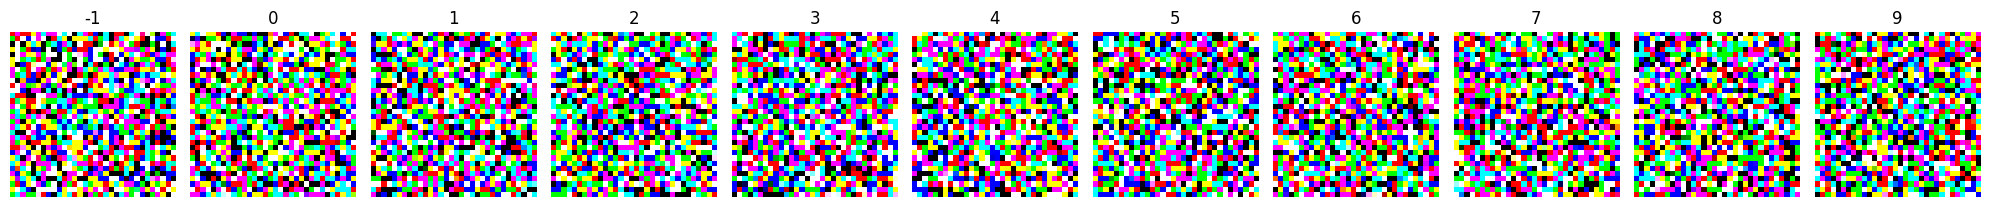

Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 50s 127ms/step - noise_loss: 0.0358 - learning_rate: 9.9606e-04
Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - noise_loss: 0.0335 - learning_rate: 9.9114e-04
Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - noise_loss: 0.0327 - learning_rate: 9.8429e-04
Epoch 5/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 105s 181ms/step - noise_loss: 0.0323 - val_image_loss: 0.4711 - val_loss: 0.0613 - val_noise_loss: 0.0613 - learning_rate: 9.7553e-04
Epoch 6/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 125ms/step - noise_loss: 0.0315 - learning_rate: 9.6489e-04


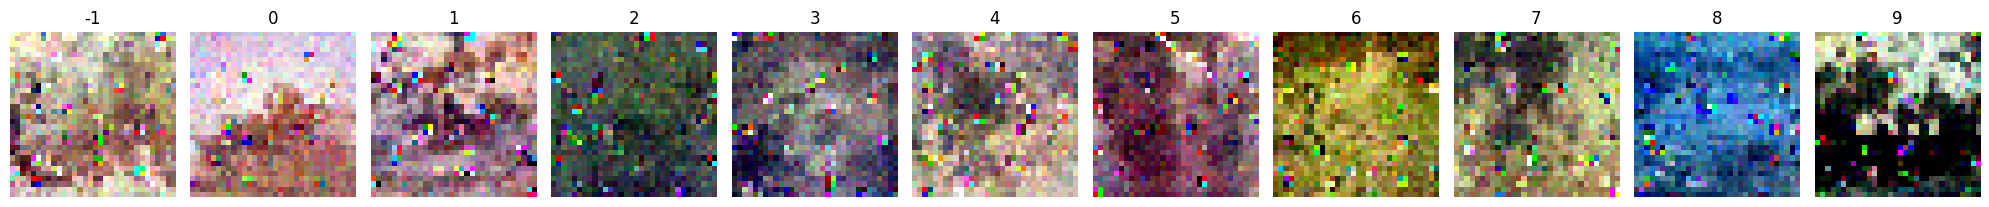

Epoch 7/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - noise_loss: 0.0314 - learning_rate: 9.5241e-04
Epoch 8/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 126ms/step - noise_loss: 0.0314 - learning_rate: 9.3815e-04
Epoch 9/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 54s 137ms/step - noise_loss: 0.0311 - learning_rate: 9.2216e-04
Epoch 10/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 63s 162ms/step - noise_loss: 0.0307 - val_image_loss: 0.1136 - val_loss: 0.0335 - val_noise_loss: 0.0335 - learning_rate: 9.0451e-04
Epoch 11/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 55s 142ms/step - noise_loss: 0.0309 - learning_rate: 8.8526e-04


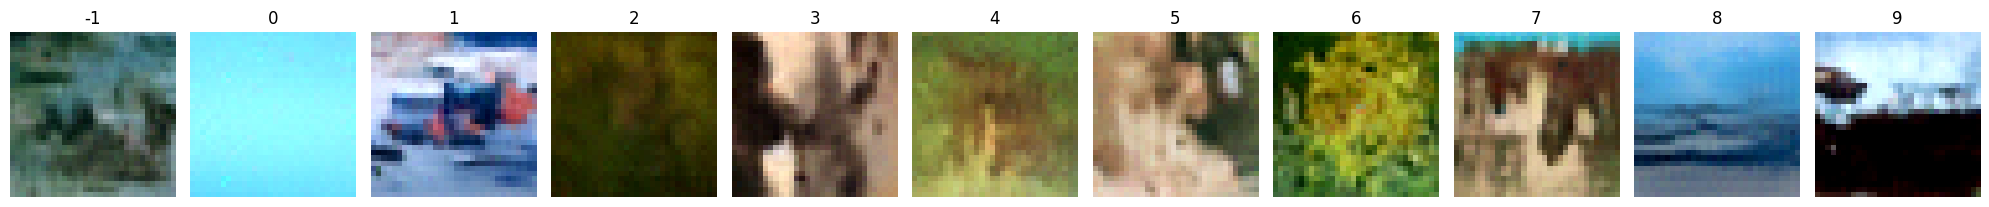

Epoch 12/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 56s 142ms/step - noise_loss: 0.0306 - learning_rate: 8.6448e-04
Epoch 13/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 54s 140ms/step - noise_loss: 0.0308 - learning_rate: 8.4227e-04
Epoch 14/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 55s 141ms/step - noise_loss: 0.0304 - learning_rate: 8.1871e-04
Epoch 15/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - noise_loss: 0.0302 - val_image_loss: 0.0881 - val_loss: 0.0320 - val_noise_loss: 0.0320 - learning_rate: 7.9389e-04
Epoch 16/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - noise_loss: 0.0305 - learning_rate: 7.6791e-04


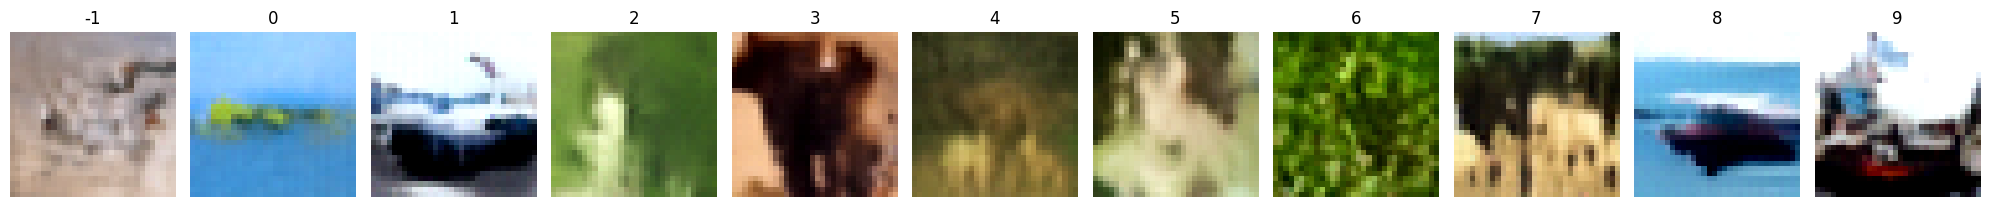

Epoch 17/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 124ms/step - noise_loss: 0.0304 - learning_rate: 7.4088e-04
Epoch 18/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - noise_loss: 0.0301 - learning_rate: 7.1289e-04
Epoch 19/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 50s 129ms/step - noise_loss: 0.0302 - learning_rate: 6.8406e-04
Epoch 20/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 61s 156ms/step - noise_loss: 0.0301 - val_image_loss: 0.0853 - val_loss: 0.0319 - val_noise_loss: 0.0319 - learning_rate: 6.5451e-04
Epoch 21/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 58s 148ms/step - noise_loss: 0.0300 - learning_rate: 6.2435e-04


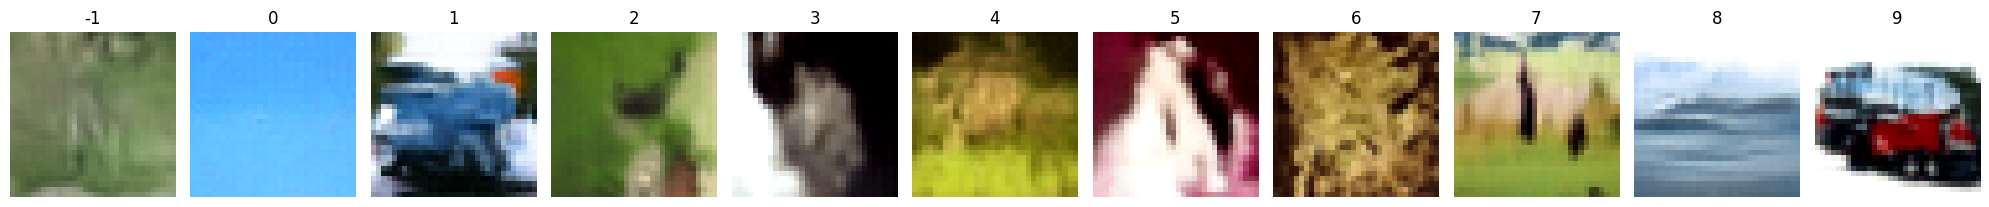

Epoch 22/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 56s 144ms/step - noise_loss: 0.0298 - learning_rate: 5.9369e-04
Epoch 23/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 54s 139ms/step - noise_loss: 0.0299 - learning_rate: 5.6267e-04
Epoch 24/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 50s 129ms/step - noise_loss: 0.0300 - learning_rate: 5.3140e-04
Epoch 25/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - noise_loss: 0.0300 - val_image_loss: 0.0836 - val_loss: 0.0319 - val_noise_loss: 0.0319 - learning_rate: 5.0000e-04
Epoch 26/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - noise_loss: 0.0296 - learning_rate: 4.6860e-04


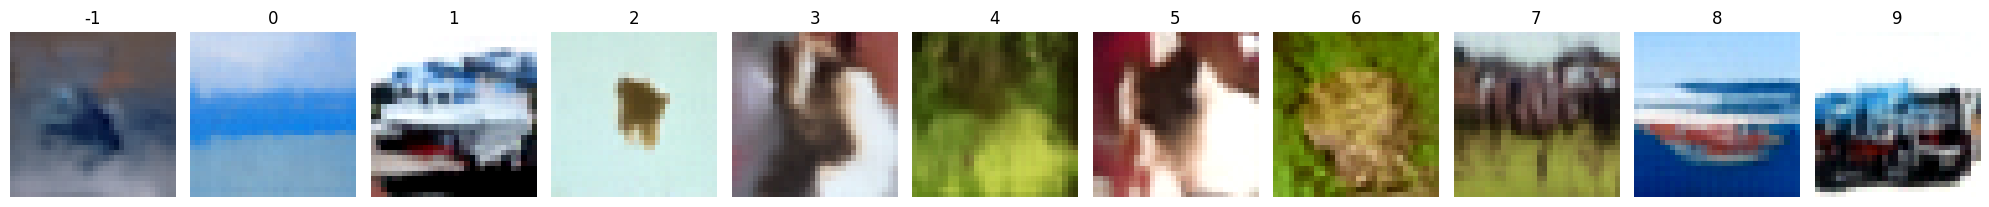

Epoch 27/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - noise_loss: 0.0300 - learning_rate: 4.3733e-04
Epoch 28/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 54s 138ms/step - noise_loss: 0.0297 - learning_rate: 4.0631e-04
Epoch 29/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 55s 140ms/step - noise_loss: 0.0296 - learning_rate: 3.7566e-04
Epoch 30/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 65s 167ms/step - noise_loss: 0.0297 - val_image_loss: 0.0834 - val_loss: 0.0319 - val_noise_loss: 0.0319 - learning_rate: 3.4549e-04
Epoch 31/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - noise_loss: 0.0295 - learning_rate: 3.1594e-04


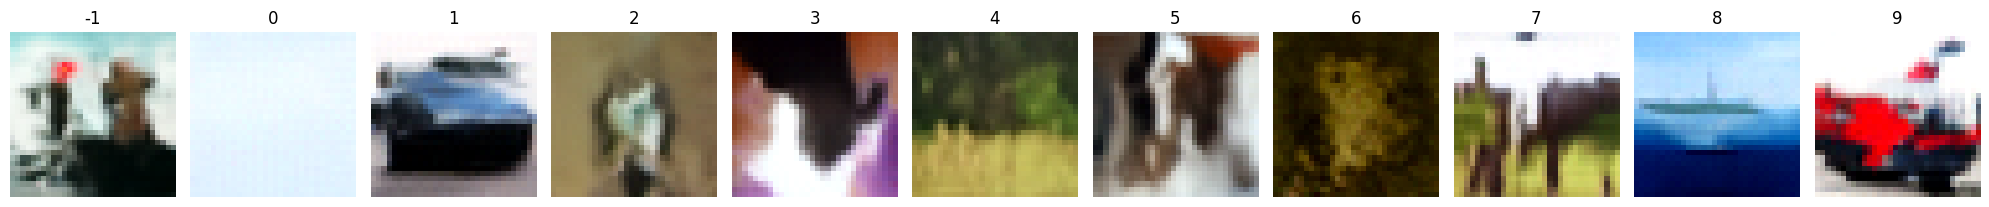

Epoch 32/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 47s 121ms/step - noise_loss: 0.0295 - learning_rate: 2.8711e-04
Epoch 33/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 126ms/step - noise_loss: 0.0294 - learning_rate: 2.5912e-04
Epoch 34/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - noise_loss: 0.0296 - learning_rate: 2.3209e-04
Epoch 35/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 57s 146ms/step - noise_loss: 0.0293 - val_image_loss: 0.0827 - val_loss: 0.0322 - val_noise_loss: 0.0322 - learning_rate: 2.0611e-04
Epoch 36/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 126ms/step - noise_loss: 0.0293 - learning_rate: 1.8129e-04


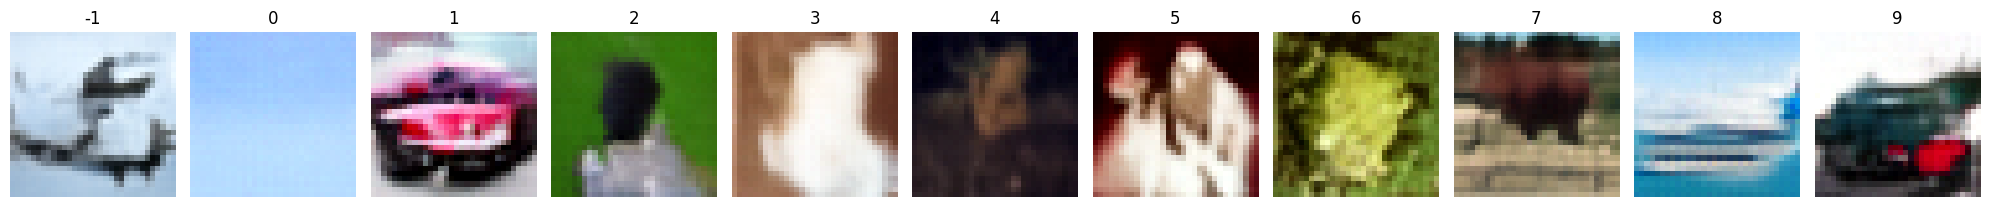

Epoch 37/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 48s 124ms/step - noise_loss: 0.0291 - learning_rate: 1.5773e-04
Epoch 38/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 125ms/step - noise_loss: 0.0294 - learning_rate: 1.3552e-04
Epoch 39/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 125ms/step - noise_loss: 0.0293 - learning_rate: 1.1474e-04
Epoch 40/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 56s 143ms/step - noise_loss: 0.0294 - val_image_loss: 0.0813 - val_loss: 0.0324 - val_noise_loss: 0.0324 - learning_rate: 9.5491e-05
Epoch 41/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 125ms/step - noise_loss: 0.0293 - learning_rate: 7.7836e-05


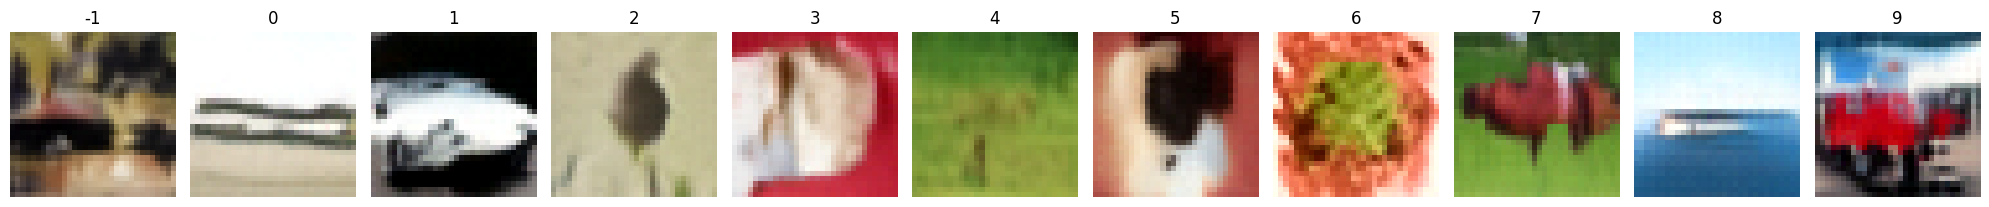

Epoch 42/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 124ms/step - noise_loss: 0.0291 - learning_rate: 6.1847e-05
Epoch 43/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 125ms/step - noise_loss: 0.0292 - learning_rate: 4.7586e-05
Epoch 44/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 126ms/step - noise_loss: 0.0293 - learning_rate: 3.5112e-05
Epoch 45/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 56s 144ms/step - noise_loss: 0.0293 - val_image_loss: 0.0813 - val_loss: 0.0323 - val_noise_loss: 0.0323 - learning_rate: 2.4472e-05
Epoch 46/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 50s 129ms/step - noise_loss: 0.0291 - learning_rate: 1.5708e-05


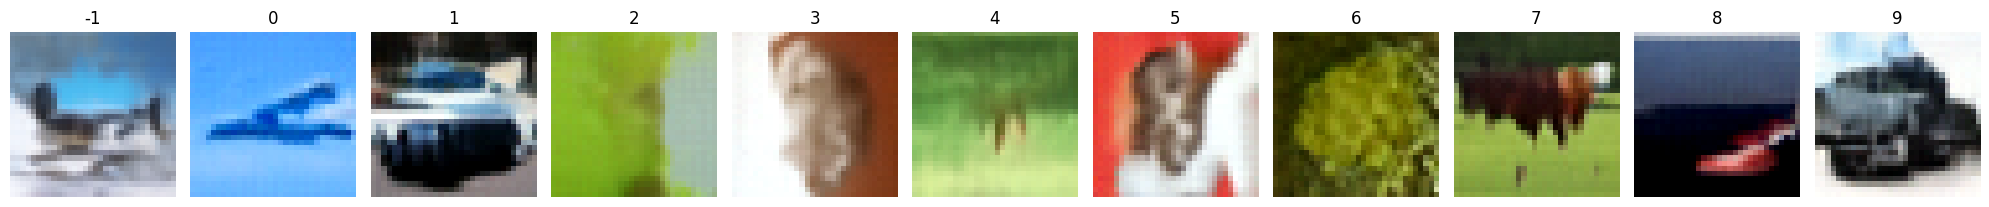

Epoch 47/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 125ms/step - noise_loss: 0.0294 - learning_rate: 8.8564e-06
Epoch 48/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 49s 126ms/step - noise_loss: 0.0289 - learning_rate: 3.9426e-06
Epoch 49/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 47s 121ms/step - noise_loss: 0.0294 - learning_rate: 9.8664e-07
Epoch 50/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 52s 134ms/step - noise_loss: 0.0292 - val_image_loss: 0.0857 - val_loss: 0.0315 - val_noise_loss: 0.0315 - learning_rate: 0.0000e+00


In [9]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list, 
    validation_freq=val_freq
).history

In [10]:
model.save_weights("./models/CIFAR10 DiT/model.weights.h5")

In [11]:
model.evaluate(valset, network_name="ema")

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - image_loss: 0.0811 - loss: 0.0325 - noise_loss: 0.0325


[<tf.Tensor: shape=(), dtype=float32, numpy=0.03245755285024643>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.03245755285024643>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.08108548074960709>]

In [12]:
model.evaluate(valset, network_name="raw")

79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - image_loss: 0.0809 - loss: 0.0323 - noise_loss: 0.0323


[<tf.Tensor: shape=(), dtype=float32, numpy=0.03231699392199516>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.03231699392199516>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.08092493563890457>]

Steps: 1000/1000


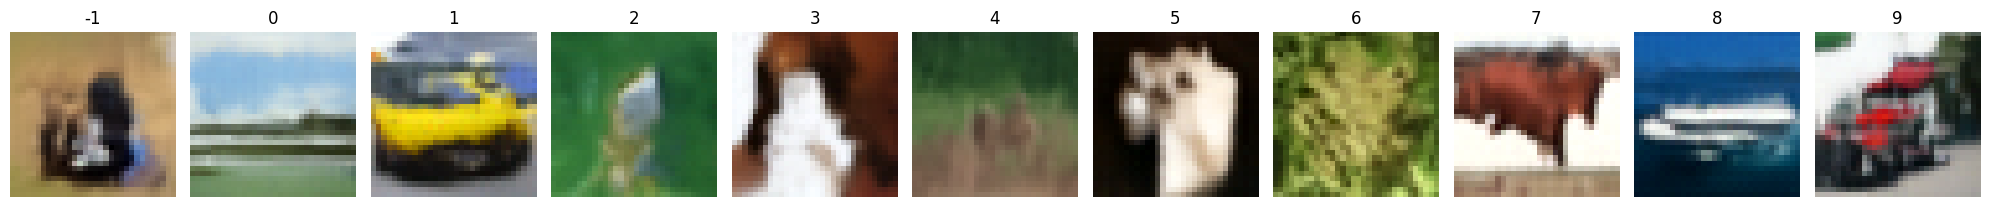

In [13]:
from common.utils import plot_images


imgs = model.sample(add_null_label=True, scale=3., eta=1., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 1000/1000


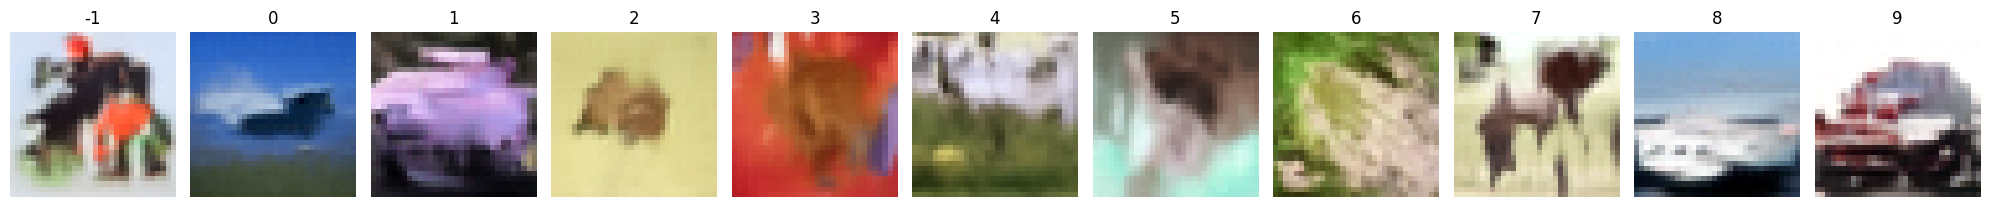

In [14]:
imgs = model.sample(add_null_label=True, scale=3., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


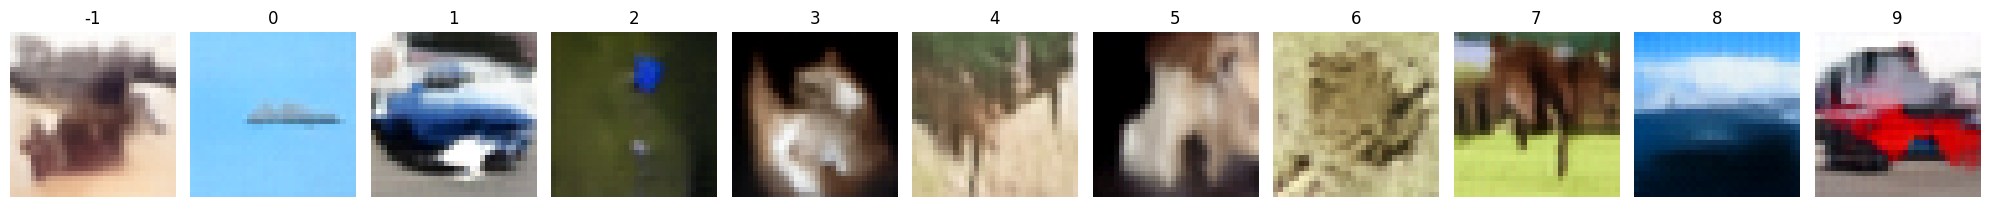

In [15]:
imgs = model.sample(add_null_label=True, scale=3., verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


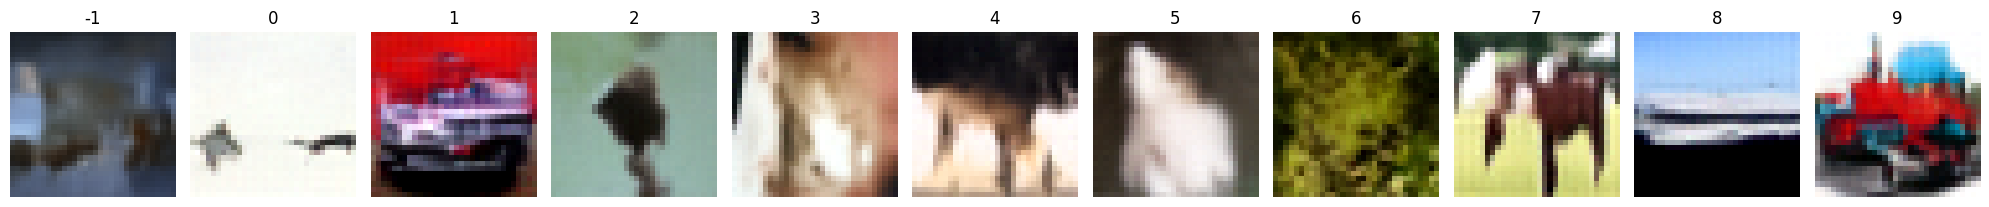

In [16]:
imgs = model.sample(add_null_label=True, scale=4., verbose=True)
plot_images(imgs, has_null_label=True)

In [18]:
history.pop("val_noise_loss")

[0.06130560487508774,
 0.03352433815598488,
 0.032017722725868225,
 0.031894564628601074,
 0.031860820949077606,
 0.03191588446497917,
 0.032193005084991455,
 0.032395415008068085,
 0.032281938940286636,
 0.03154658153653145]

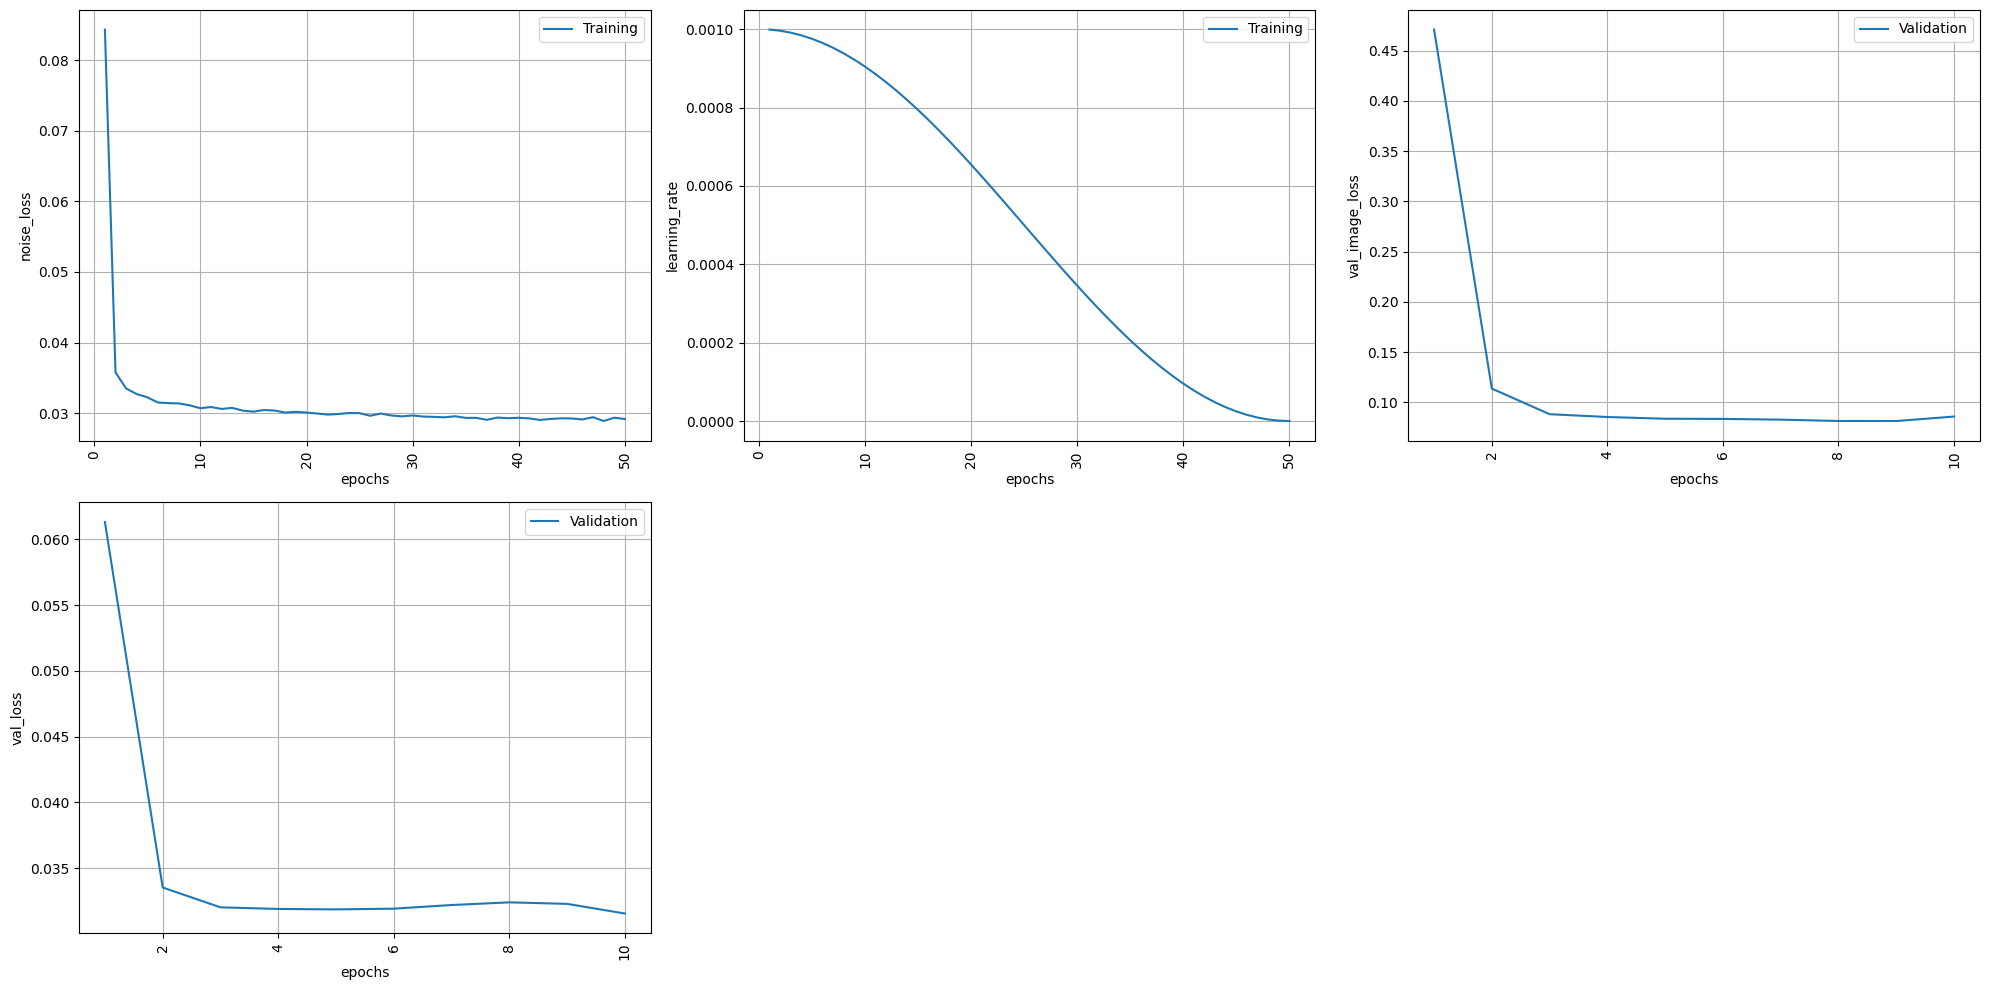

In [19]:
from common.utils import plot_history


plot_history(history, show_all_x_ticks=False)

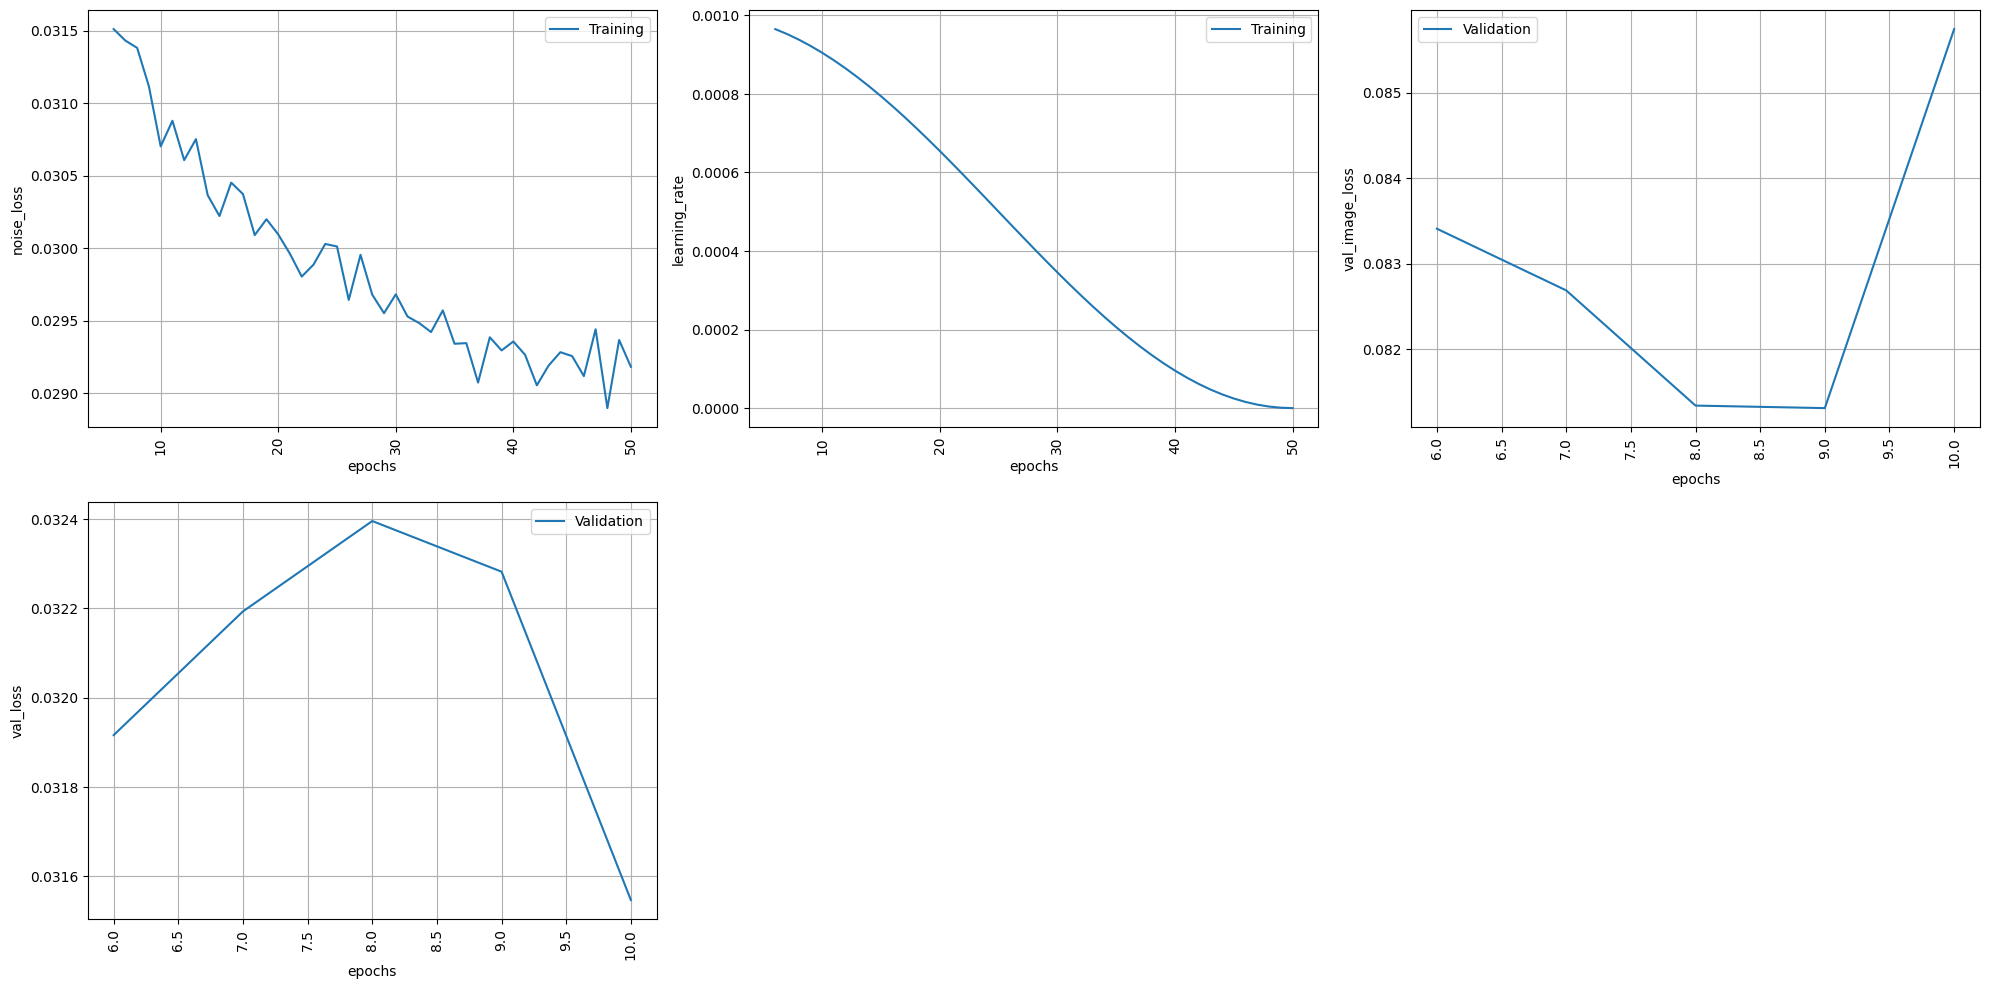

In [21]:
plot_history(history, show_all_x_ticks=False, range_=(5, None))